In [13]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
from scipy.io import wavfile
import os
import tensorflow as tf

In [ ]:
# conjunto treino

# conjunto teste

### Separação da entrada
O conjunto de dados é dado no formato:

- final_0402_1:
	- dev_set:
	    - sount_event/train:
			- Classes:
				- Canais separados com diversos tipos de som para cada classe
		- test/oracle_target:
			- dev_test_*_Classe.wav
				- (esses arquivos contem os arquivos da pasta anterior mas agroupados em testes pelo numero e com tamanho de 10 segundos)

Para este trabalho vamos agrupar todas as classes, para que desta forma o modelo aprenda o comportamento do nosso subset escolhido mesmo quando apresentamos outros tipos de som parecidos. Também adicionaremos tipos diferentes de ruidos.

In [ ]:
SAMPLE_RATE=32000
DESIRED_CLASSES=['BicycleBell', 'Cough', 'MusicalKeyboard', 'Percussion', 'Doorbell']
N_FFT=1024
HOP_LENGHT=512
N_MELS=128

In [ ]:
# DO NOT RUN
base_path = './final_0402_1/DCASE2025Task4Dataset/dev_set/test/oracle_target'

all_groupped_by_test = {}
desired_tests = {}
test_audios = {}

for file_name in os.listdir(base_path):
	file_path = os.path.join(base_path, file_name)

	_, _, case, audioClass = file_name[:file_name.find(".")].split("_")
	if case not in all_groupped_by_test.keys():
		all_groupped_by_test[case] = [file_path]
	else:
		all_groupped_by_test[case] += [file_path]

for (case, paths) in all_groupped_by_test.items():
	classes = [w[w.rfind("_")+1:w.rfind(".")] for w in paths]
	if not any([cla in classes for cla in DESIRED_CLASSES]):
		continue
	desired_tests[case] = paths, classes

for idx, (case, (paths, classes)) in enumerate(desired_tests.items()):
	raw = [wavfile.read(path) for path in paths]
	sample_rates, audios = [r[0] for r in raw], [r[1] for r in raw]
	if any([sr != sample_rates[0] for sr in sample_rates]):
		print("Wrong sample rate on set")
		break
	combined_audio = audios[0]
	for i in range(1, len(audios)):
		combined_audio += audios[i]
	
	maxi = max(combined_audio.astype(np.int64).max(), np.abs(combined_audio.astype(np.int64).min()))
	combined_audio = np.divide(combined_audio, maxi)
	mel_spectrogram = librosa.feature.melspectrogram(
		y=combined_audio, 
		sr=SAMPLE_RATE, 
		n_fft=N_FFT,
		hop_length=HOP_LENGHT,
		n_mels=N_MELS
		)
	mel_s_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
	test_audios[case] = (sample_rates[0], combined_audio, mel_spectrogram)

	target_file_wav = os.path.join("tests", "case_%04d.wav" % (idx))
	target_file_npy = os.path.join("tests", "case_%04d.npy" % (idx))
	target_file_txt = os.path.join("tests", "case_%04d.txt" % (idx))
	if os.path.exists(target_file_wav):
		os.remove(target_file_wav)
	if os.path.exists(target_file_npy):
		os.remove(target_file_npy)
	if os.path.exists(target_file_txt):
		os.remove(target_file_txt)
	wavfile.write(target_file_wav, sample_rates[0], combined_audio.astype(float))
	np.save(target_file_npy, mel_spectrogram)
	with open(target_file_txt, '+x') as file:
		file.write(",".join(classes))

In [ ]:
base_path = './tests'
test_cases = []
paths = os.listdir(base_path)
paths = sorted(paths)
for file_name in paths:
	caseNumber = int(file_name[5:9])
	tip = 0
	file_path = os.path.join(base_path,file_name)
	if file_name.endswith("wav"):
		tip = 0
		_, data = wavfile.read(file_path)
	elif file_name.endswith("npy"):
		tip = 1
		data = np.load(file_path)
	elif file_name.endswith("txt"):
		tip = 2
		with open(file_path, 'r') as file:
			data = file.readline()
	if len(test_cases) <= caseNumber:
		test_cases += [[0,0,""]]
	test_cases[caseNumber][tip] = data

[array([-3.28299409e-05, -3.28299409e-05, -3.28299409e-05, ...,
       -2.69205515e-03, -1.81877873e-02, -1.06697308e-02], shape=(320000,)), array([[2.86304772e-07, 5.10527614e-07, 4.72011295e-07, ...,
        1.46673793e-06, 2.77432645e-06, 1.18922664e-05],
       [9.02893016e-08, 5.23992805e-08, 5.72868011e-08, ...,
        9.73400953e-07, 1.80810381e-06, 1.50627119e-05],
       [2.45287027e-08, 8.92285213e-10, 6.35186976e-08, ...,
        2.81011853e-05, 2.63077154e-05, 1.15985696e-05],
       ...,
       [4.29779120e-10, 1.83282080e-09, 8.60564213e-06, ...,
        3.00909675e-05, 4.04520191e-05, 1.61196745e-05],
       [3.80754758e-10, 1.60357711e-09, 2.24384429e-06, ...,
        1.50589548e-05, 2.20301935e-05, 1.37941248e-05],
       [8.52006130e-10, 9.91884258e-10, 4.66188574e-08, ...,
        6.51280381e-07, 9.98087657e-07, 2.09099726e-06]], shape=(128, 626)), 'MechanicalFans,Blender,MusicalKeyboard']


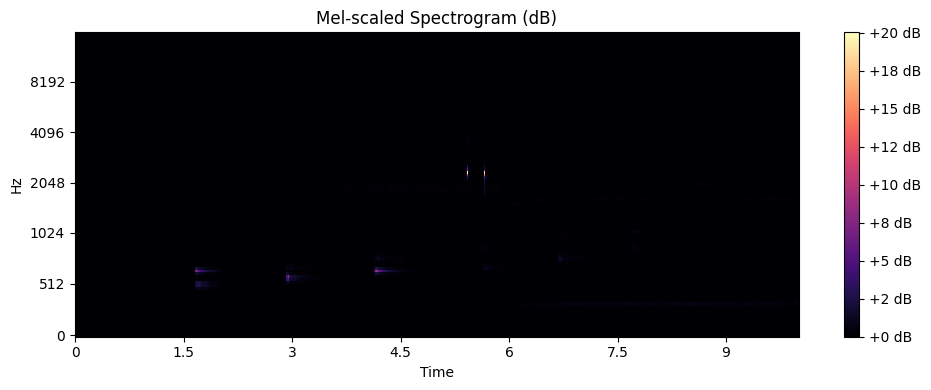

In [ ]:
print(test_cases[18])
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    test_cases[18][1], 
    sr=SAMPLE_RATE, 
    hop_length=HOP_LENGHT, 
    x_axis='time', 
    y_axis='mel', 
    cmap='magma'
)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-scaled Spectrogram (dB)')
plt.tight_layout()
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

### Transfer Learning

Formato original: (128, 626)
Formato preparado para o modelo: (1, 128, 128, 1)


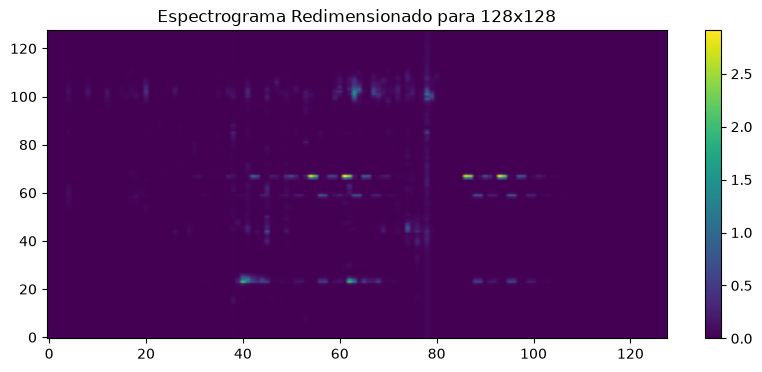

In [14]:
# Carregando o arquivo .npy
data = np.load('./tests/case_0000.npy')
print(f'Formato original: {data.shape}')

# Redimensionando para 128x128 (formato esperado pelo seu modelo)
# O TensorFlow espera (H, W, C) para redimensionar
img_tensor = data[..., np.newaxis]
img_resized = tf.image.resize(img_tensor, [128, 128]).numpy()

# Adicionando dimensão de batch: (1, 128, 128, 1)
input_data = np.expand_dims(img_resized, axis=0)
print(f'Formato preparado para o modelo: {input_data.shape}')

# Visualizando o espectrograma redimensionado
plt.figure(figsize=(10, 4))
plt.imshow(img_resized.squeeze(), aspect='auto', origin='lower')
plt.title('Espectrograma Redimensionado para 128x128')
plt.colorbar()
plt.show()

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Recriando o base_model para garantir que ele esteja disponível
base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
base_model.trainable = False

# 1. Definir a entrada (128x128)
inputs = layers.Input(shape=(128, 128, 1))

# 2. Replicar o canal único 3 vezes para simular RGB, exigido pelo EfficientNetB0
x = layers.Concatenate()([inputs, inputs, inputs])

# 3. Pré-processamento e Base
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)

# 5. Cabeça de classificação (Top)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.2)(x) # Regularização para dataset pequeno
outputs = layers.Dense(10, activation='relu')(x)

model = models.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 128, 128,  │          0 │ input_layer_9[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_9[0]… │
│                     │                   │            │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 4, 4,      │  4,049,571 │ concatenate_4[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 10)        │      2,570 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [26]:
# Agora o 'model' e o 'input_data' estão definidos corretamente
prediction = model.predict(input_data)
print(f'\nResultado da predição (probabilidades):\n{prediction}')
print(f'Classe predita: {np.argmax(prediction)}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Resultado da predição (probabilidades):
[[0.10956388 0.11117168 0.07386918 0.         0.         0.
  0.22689147 0.         0.21889031 0.        ]]
Classe predita: 6
